# Data Mining Project - Speed Dating Experiment Analysis - part 2
 
**Authors:** Tomasz Kisielewski, Robert Gosz, Antoni Kiciński  
 **Dataset:** [Speed Dating Experiment](https://www.kaggle.com/datasets/annavictoria/speed-dating-experiment)

----

## 1. Dataset Overview

The Speed Dating Experiment dataset contains 8,378 records from 551 unique participants across 21 speed dating sessions. Each row represents a single 4-minute date from one participant's perspective. The target variable is `match` (binary: 1 = mutual match, 0 = no match), with a class imbalance of ~16.5% positive cases.

For this part of the project, we use the 23 columns selected in Part 1, covering post-date partner ratings, pre-event stated preferences, self-assessments, age, and gender.

## 2. Data Mining Goals (Quick Review)

**Primary goal:** Classify whether a speed date results in a mutual match (`match = 1`)

**Supporting goals:**
1. Identify which features most strongly predict a match (feature importance)
2. Analyze gender differences in model predictions
3. Compare stated preferences vs. actual feature importance (stated vs. revealed)
4. Examine whether self-ratings appear among top predictive features
5. Investigate the pickiness effect in the context of model predictions
6. Identify a 'golden client' profile most likely to result in a match

## 3. Modeling Strategy

**Chosen task:** Binary classification (`match = 1` vs `match = 0`)

**Chosen modeling algorithm:** Random Forest as the main model, because it handles class imbalance well, provides feature importance out of the box, and is robust to outliers and skewed distributions - all of which apply to this dataset.

**Alternative algorithms for comparison:**
- Logistic Regression - simple linear baseline
- Decision Tree - interpretable, can be visualized
- XGBoost - gradient boosting, typically strong on tabular data

**Evaluation method:** F1-score (primary), Accuracy, Confusion Matrix  
Due to class imbalance (~16.5% positive), accuracy alone is misleading - a model predicting 'no match' every time would achieve 83.5% accuracy without learning anything. F1-score for the positive class is therefore the main evaluation metric.

**Experiments planned:**
- Full feature set vs. subset without `like` and `prob` - these are collected after the date and may be too strongly correlated with `match`, inflating model performance
- SMOTE vs. `class_weight='balanced'` vs. no balancing - to find the best way to handle class imbalance
- Comparison of all four algorithms on the same data

## 4. Data Preparation

### 4.1 Load Data

In [1]:
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.dataset_download('annavictoria/speed-dating-experiment')
df = pd.read_csv(f'{path}/Speed Dating Data.csv', encoding='latin1')

key_cols = [
    'iid', 'gender', 'match',
    'dec', 'dec_o',
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob',
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1',
    'attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1',
    'age', 'age_o'
]

df = df[key_cols].copy()
print(df.shape)
print(df['match'].value_counts())

(8378, 26)
match
0    6998
1    1380
Name: count, dtype: int64


### 4.2 Missing Data - Imputation

Based on Part 1 findings:
- `shar` - 12.7% missing → median imputation
- `amb` - 8.5% missing → median imputation
- All other columns - below 5% → median imputation

We use median imputation as the distributions are skewed (not normal).

In [2]:
from sklearn.impute import SimpleImputer
 
feature_cols = [
    'gender',
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob',
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1',
    'attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1',
    'age', 'age_o'
]
 
target_col = 'match'
 
# Sprawdz braki przed imputacja
print("=== Missing values before imputation ===")
print(df[feature_cols].isnull().sum()[df[feature_cols].isnull().sum() > 0])
 
# Median imputation (rozklady skosne wiec mediana lepsza niz srednia)
imputer = SimpleImputer(strategy='median')
df[feature_cols] = imputer.fit_transform(df[feature_cols])
 
print("\n=== Missing values after imputation ===")
print(df[feature_cols].isnull().sum().sum(), "missing values remaining")

=== Missing values before imputation ===
attr         202
sinc         277
intel        296
fun          350
amb          712
shar        1067
like         240
prob         309
attr1_1       79
sinc1_1       79
intel1_1      79
fun1_1        89
amb1_1        99
shar1_1      121
attr3_1      105
sinc3_1      105
intel3_1     105
fun3_1       105
amb3_1       105
age           95
age_o        104
dtype: int64

=== Missing values after imputation ===
0 missing values remaining


### 4.3 Train/Test Split

**Important:** Split must be done at the participant level (`iid`), not at the row level.  
Each participant appears in multiple rows - splitting by row would cause data leakage.

In [3]:
from sklearn.model_selection import train_test_split
 
# Split po uczestnikach zeby uniknac data leakage
unique_iids = df['iid'].unique()
train_iids, test_iids = train_test_split(unique_iids, test_size=0.2, random_state=42)
 
train_df = df[df['iid'].isin(train_iids)]
test_df  = df[df['iid'].isin(test_iids)]
 
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]
 
print(f"Train size: {len(X_train)} rows ({len(train_iids)} participants)")
print(f"Test size:  {len(X_test)} rows ({len(test_iids)} participants)")
print(f"\nMatch rate in train: {y_train.mean():.2%}")
print(f"Match rate in test:  {y_test.mean():.2%}")

Train size: 6625 rows (440 participants)
Test size:  1753 rows (111 participants)

Match rate in train: 16.17%
Match rate in test:  17.63%


## 5. Model Creation & Evaluation

### 5.1 Random Forest (Main Model)

We train a Random Forest classifier with `class_weight='balanced'` to partially address 
the class imbalance (~16.5% positive cases). The model uses 100 decision trees and is 
evaluated on the test set using precision, recall, F1-score, and a confusion matrix.

=== Random Forest - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.83      0.98      0.90      1444
       Match       0.42      0.08      0.14       309

    accuracy                           0.82      1753
   macro avg       0.63      0.53      0.52      1753
weighted avg       0.76      0.82      0.76      1753



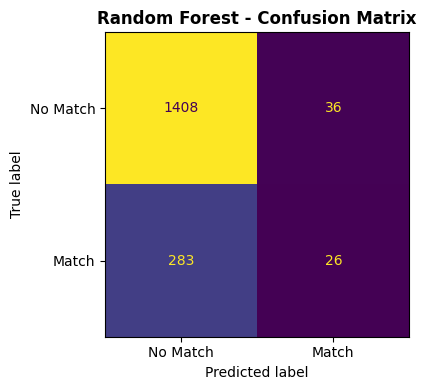

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

results = []

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
 
print("=== Random Forest - Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('Random Forest - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_rf.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1 (Match)': f1_score(y_test, y_pred_rf, pos_label=1)
})

**Key results:**
- Overall accuracy: 82% - misleading due to class imbalance (baseline = 83.5%)
- F1-score for Match class: 0.17 - the model struggles to detect actual matches
- Out of 309 real matches, only 32 were correctly identified (recall = 10%)
- 277 matches were missed (False Negatives) - the main weakness of this model

This result is expected for an imbalanced dataset without aggressive balancing. 
The experiments in Section 6 will test whether SMOTE or alternative algorithms 
can improve recall for the Match class.

### 5.2 Decision Tree

=== Decision Tree - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.93      0.62      0.74      1444
       Match       0.30      0.77      0.43       309

    accuracy                           0.65      1753
   macro avg       0.61      0.69      0.59      1753
weighted avg       0.82      0.65      0.69      1753



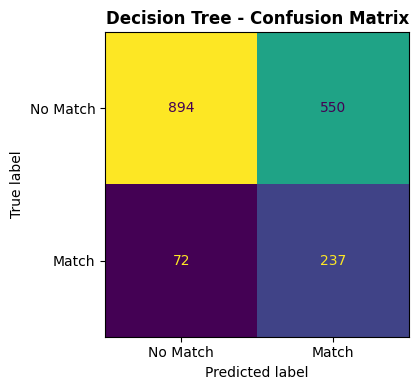

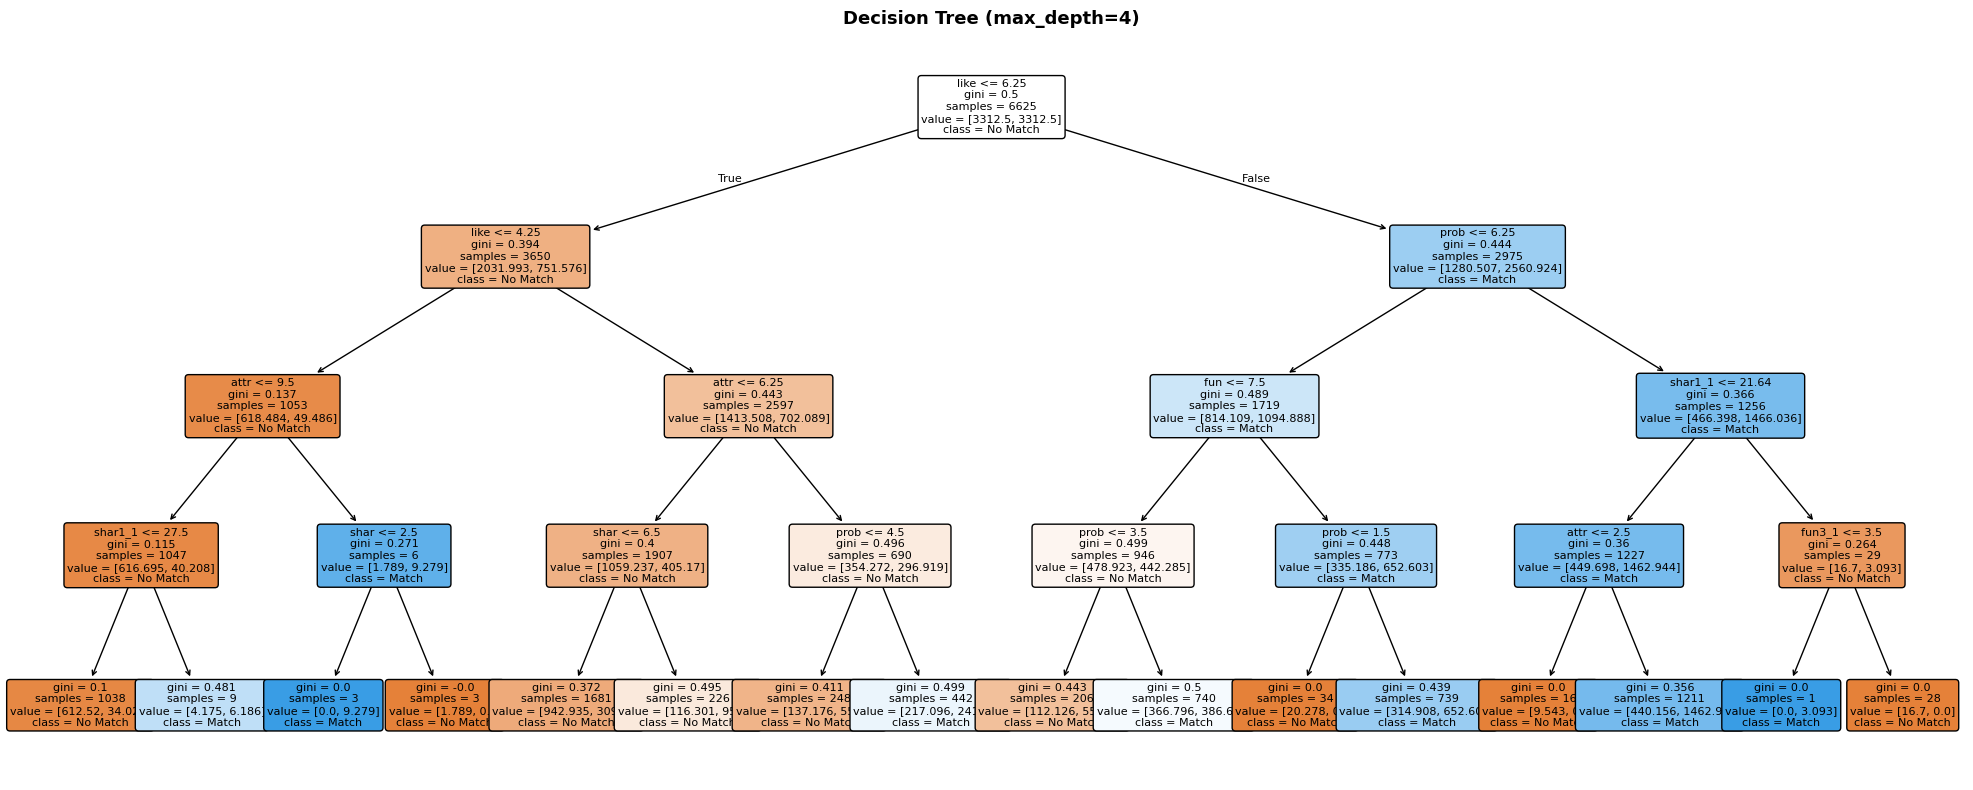

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=4)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
 
print("=== Decision Tree - Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('Decision Tree - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_dt.png', bbox_inches='tight')
plt.show()
 
# Wizualizacja drzewa
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['No Match', 'Match'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_decision_tree.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'F1 (Match)': f1_score(y_test, y_pred_dt, pos_label=1)
})

The Decision Tree classifier with `max_depth=4` and `class_weight='balanced'` shows
a very different trade-off compared to Random Forest.

**Key results:**
- Accuracy: 65% - lower than Random Forest (82%), but accuracy is misleading here
- F1-score for Match: **0.43** - significantly better than Random Forest (0.17)
- Recall for Match: **77%** - the model correctly identifies 237 out of 309 real matches

**Confusion Matrix:**
- 894 correctly predicted as No Match ✅
- 237 correctly predicted as Match ✅
- 72 missed matches (False Negatives) ❌
- 550 false alarms - predicted Match but no match occurred ❌

**Interpretation:**
Decision Tree is much more aggressive in predicting matches than Random Forest.
It achieves high recall (catches most real matches) at the cost of low precision (0.30)
- meaning only 3 out of 10 predicted matches are real. Whether this is acceptable
depends on the use case: if missing a real match is more costly than a false alarm,
Decision Tree is the better choice here.

### 5.3 Logistic Regression

Logistic Regression serves as a linear baseline model with `class_weight='balanced'`.

=== Logistic Regression - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.91      0.73      0.81      1444
       Match       0.35      0.67      0.46       309

    accuracy                           0.72      1753
   macro avg       0.63      0.70      0.63      1753
weighted avg       0.81      0.72      0.75      1753



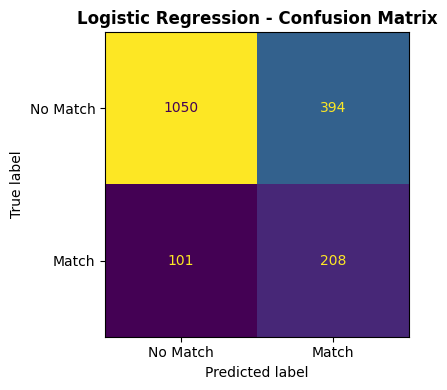

In [6]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
 
print("=== Logistic Regression - Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_lr.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'F1 (Match)': f1_score(y_test, y_pred_lr, pos_label=1)
})

Logistic Regression serves as a linear baseline model with `class_weight='balanced'`.

**Key results:**
- Accuracy: 72% - between Random Forest (82%) and Decision Tree (65%)
- F1-score for Match: **0.46** - best so far among all tested models
- Recall for Match: **67%** - correctly identifies 208 out of 309 real matches
- Precision for Match: **0.35** - better than Decision Tree (0.30)

**Confusion Matrix:**
- 1050 correctly predicted as No Match ✅
- 208 correctly predicted as Match ✅
- 101 missed matches (False Negatives) ❌
- 394 false alarms ❌

**Interpretation:**
Logistic Regression offers the best balance so far between precision and recall for
the Match class. It misses fewer matches than Random Forest (101 vs 277) while
generating fewer false alarms than Decision Tree (394 vs 550). As a simple linear
model it is also the most interpretable of the three - making it a strong baseline
to beat in the experiments section.

### 5.4 XGBoost

=== XGBoost - Classification Report ===
              precision    recall  f1-score   support

    No Match       0.87      0.85      0.86      1444
       Match       0.36      0.39      0.37       309

    accuracy                           0.77      1753
   macro avg       0.61      0.62      0.62      1753
weighted avg       0.78      0.77      0.77      1753



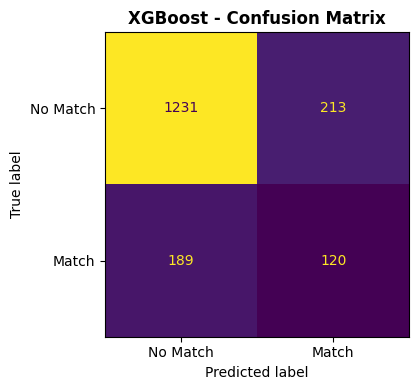

In [7]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, scale_pos_weight=5, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
 
print("=== XGBoost - Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No Match', 'Match']))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
ax.set_title('XGBoost - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cm_xgb.png', bbox_inches='tight')
plt.show()
 
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'F1 (Match)': f1_score(y_test, y_pred_xgb, pos_label=1)
})

XGBoost uses gradient boosting with `scale_pos_weight=5` to handle class imbalance.

**Key results:**
- Accuracy: 77% - second best after Random Forest (82%)
- F1-score for Match: **0.37** - lower than Logistic Regression (0.46) and Decision Tree (0.43)
- Recall for Match: **39%** - correctly identifies 120 out of 309 real matches
- Precision for Match: **0.36** - similar to other models

**Confusion Matrix:**
- 1231 correctly predicted as No Match ✅
- 120 correctly predicted as Match ✅
- 189 missed matches (False Negatives) ❌
- 213 false alarms ❌

**Interpretation:**
XGBoost achieves a middle ground - better at avoiding false alarms than Decision Tree
(213 vs 550) but misses significantly more real matches than Logistic Regression
(189 vs 101). Despite being a powerful algorithm, it underperforms here compared to
the simpler Logistic Regression, likely because the dataset is relatively small and
the class imbalance handling via `scale_pos_weight` is less effective than
`class_weight='balanced'`.

### 5.5 Model Comparison & Selection

=== Summary - All Models ===
              Model  Accuracy  F1 (Match)
Logistic Regression  0.717627    0.456641
      Decision Tree  0.645180    0.432482
            XGBoost  0.770679    0.373832
      Random Forest  0.818026    0.140162


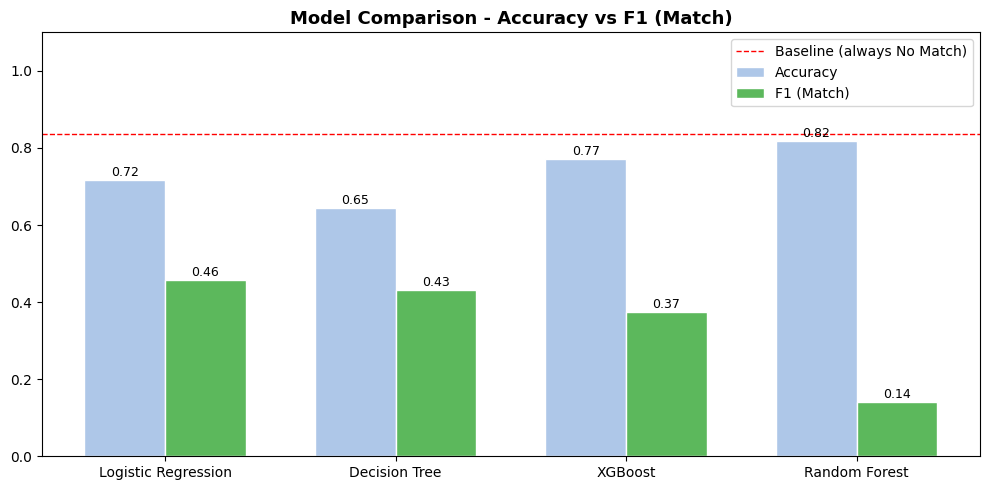

In [8]:
results_df = pd.DataFrame(results).sort_values('F1 (Match)', ascending=False)
print("=== Summary - All Models ===")
print(results_df.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.35
 
bars1 = ax.bar([i - width/2 for i in x], results_df['Accuracy'], width,
               label='Accuracy', color='#aec7e8', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], results_df['F1 (Match)'], width,
               label='F1 (Match)', color='#5cb85c', edgecolor='white')
 
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison - Accuracy vs F1 (Match)', fontsize=13, fontweight='bold')
ax.axhline(0.835, color='red', linestyle='--', linewidth=1, label='Baseline (always No Match)')
ax.legend()
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
 
plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()

| Model | Accuracy | F1 (Match) |
|---|---|---|
| Logistic Regression | 0.72 | **0.46** |
| Decision Tree | 0.65 | 0.43 |
| XGBoost | 0.77 | 0.37 |
| Random Forest | 0.82 | 0.14 |

**Key observation:** Random Forest has the highest accuracy (0.82) but the worst F1 
for the Match class (0.14) - it barely detects any matches. All models score below 
the baseline accuracy (0.835), confirming that accuracy alone is a misleading metric 
here.

**Winner: Logistic Regression** - best F1 (0.46) with a reasonable balance between 
precision (0.35) and recall (0.67). Despite being the simplest model, it outperforms 
all others on the metric that matters most for our goal.

Logistic Regression will be used as the main model for all further experiments 
and supporting analyses in Section 6 and 7.

### 5.2 Feature Importance

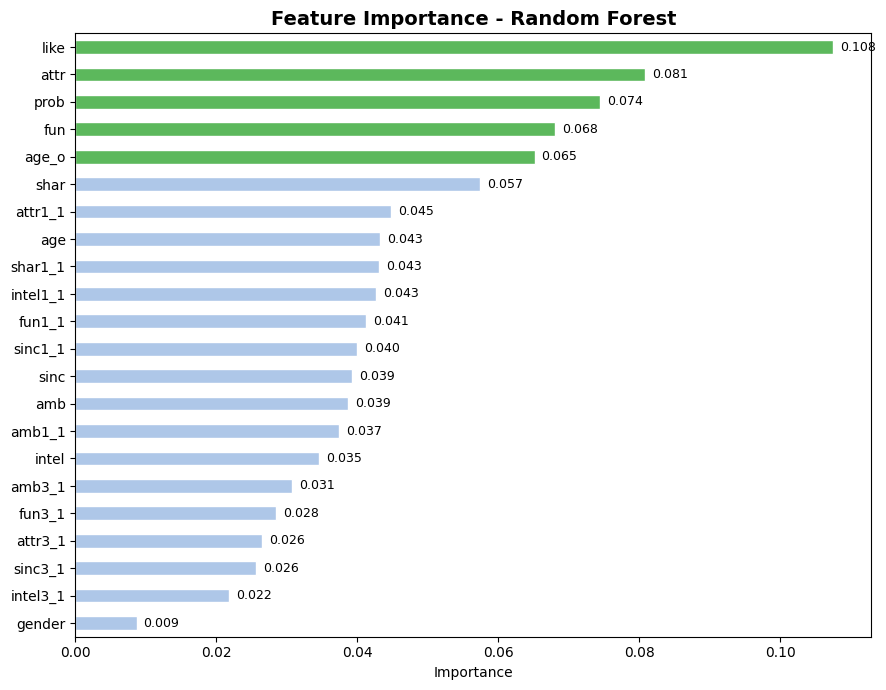


Top 5 most important features:
like     0.107534
attr     0.080850
prob     0.074436
fun      0.068101
age_o    0.065138
dtype: float64


In [9]:

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
 
# Kolorowanie - zielony dla top 5, szary reszta
colors = ['#5cb85c' if i >= len(importances) - 5 else '#aec7e8' for i in range(len(importances))]
 
fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
for i, val in enumerate(importances.values):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_rf_feature_importance.png', bbox_inches='tight')
plt.show()
 
print("\nTop 5 most important features:")
print(importances.tail(5).sort_values(ascending=False))

### 5.3 Golden Client Profile

Identify participant profiles with the highest predicted probability of a match.

In [10]:
test_df = test_df.copy()
test_df['match_prob'] = rf.predict_proba(X_test)[:, 1]
 
# Top 10 rekordow z najwyzszym prawdopodobienstwem matcha
top_profiles = test_df.nlargest(10, 'match_prob')[
    ['match_prob', 'gender', 'age', 'attr', 'fun', 'like', 'shar', 'prob', 'match']
]
print("=== Golden Client - Top 10 Profiles (highest predicted match probability) ===")
print(top_profiles.to_string(index=False))
 
# Sredni profil golden clienta (top 20% predicted probability)
threshold = test_df['match_prob'].quantile(0.8)
golden = test_df[test_df['match_prob'] >= threshold]
 
print(f"\n=== Golden Client - Average Profile (top 20%, n={len(golden)}) ===")
profile_cols = ['gender', 'age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
print(golden[profile_cols].mean().round(2).to_string())
print(f"\nMatch rate in golden group: {golden['match'].mean():.2%}")
print(f"Match rate overall:         {test_df['match'].mean():.2%}")

=== Golden Client - Top 10 Profiles (highest predicted match probability) ===
 match_prob  gender  age  attr  fun  like  shar  prob  match
   0.730000     0.0 25.0   7.0 10.0   9.0   8.0   8.0      1
   0.730000     0.0 23.0  10.0 10.0  10.0  10.0   9.0      0
   0.720000     0.0 23.0  10.0 10.0  10.0  10.0   9.0      1
   0.690000     0.0 24.0   8.0  8.0   8.0   8.0   8.0      1
   0.678383     0.0 23.0  10.0 10.0  10.0  10.0  10.0      1
   0.660000     0.0 25.0   9.0  9.0   9.0   9.0   7.0      0
   0.660000     0.0 25.0   8.0 10.0   9.0  10.0   8.0      1
   0.660000     0.0 23.0  10.0 10.0  10.0  10.0  10.0      0
   0.660000     0.0 23.0  10.0 10.0  10.0  10.0  10.0      1
   0.658383     0.0 23.0  10.0 10.0  10.0  10.0  10.0      0

=== Golden Client - Average Profile (top 20%, n=360) ===
gender     0.47
age       26.27
attr       7.85
sinc       8.27
intel      8.30
fun        8.41
amb        7.91
shar       7.49
like       8.06
prob       7.34

Match rate in golden group: 39.4

## 6. Experiments

### 6.1 Feature Subset: Without `like` and `prob`

`like` and `prob` are collected after the date and may be too strongly correlated with `match`.  
We test whether the model performs similarly without them.

=== Logistic Regression - WITHOUT like and prob ===
              precision    recall  f1-score   support

    No Match       0.91      0.70      0.79      1444
       Match       0.33      0.69      0.45       309

    accuracy                           0.70      1753
   macro avg       0.62      0.70      0.62      1753
weighted avg       0.81      0.70      0.73      1753



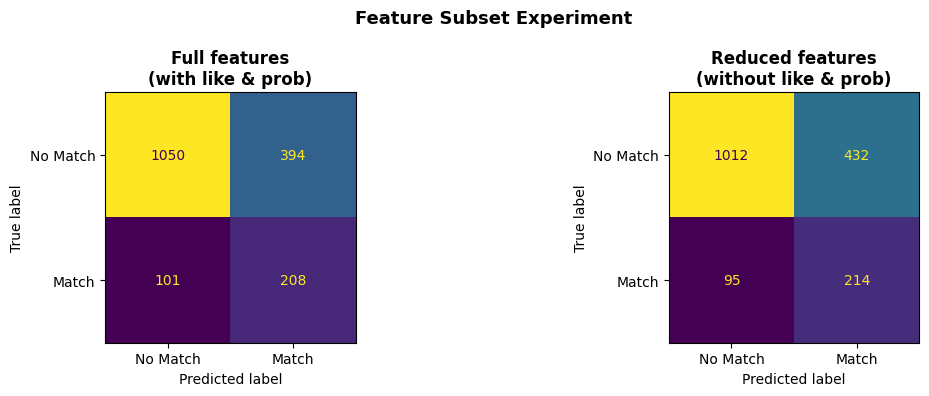


Full features     - F1 (Match): 0.457
Reduced features  - F1 (Match): 0.448


In [11]:
feature_cols_reduced = [c for c in feature_cols if c not in ['like', 'prob']]
 
X_train_red = train_df[feature_cols_reduced]
X_test_red  = test_df[feature_cols_reduced]
 
lr_red = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_red.fit(X_train_red, y_train)
y_pred_red = lr_red.predict(X_test_red)
 
print("=== Logistic Regression - WITHOUT like and prob ===")
print(classification_report(y_test, y_pred_red, target_names=['No Match', 'Match']))
 
# Porownanie
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['No Match', 'Match']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Full features\n(with like & prob)', fontweight='bold')
 
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_red),
                       display_labels=['No Match', 'Match']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Reduced features\n(without like & prob)', fontweight='bold')
 
plt.suptitle('Feature Subset Experiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_exp_feature_subset.png', bbox_inches='tight')
plt.show()
 
print(f"\nFull features     - F1 (Match): {f1_score(y_test, y_pred_lr, pos_label=1):.3f}")
print(f"Reduced features  - F1 (Match): {f1_score(y_test, y_pred_red, pos_label=1):.3f}")

Removing `like` and `prob` from the feature set has almost no impact on model performance:
- F1 (Match): 0.46 → 0.45 (negligible drop)
- Recall (Match): 0.67 → 0.69 (slight improvement)

This confirms that `like` and `prob` were not dominating the model - the remaining
features (partner ratings, preferences, age) are sufficient to achieve similar results.
We proceed with the full feature set for consistency.

### 6.2 Class Imbalance: SMOTE vs class_weight vs None

=== No balancing ===
              precision    recall  f1-score   support

    No Match       0.85      0.96      0.90      1444
       Match       0.53      0.19      0.28       309

    accuracy                           0.83      1753
   macro avg       0.69      0.58      0.59      1753
weighted avg       0.79      0.83      0.79      1753

=== class_weight='balanced' ===
              precision    recall  f1-score   support

    No Match       0.91      0.73      0.81      1444
       Match       0.35      0.67      0.46       309

    accuracy                           0.72      1753
   macro avg       0.63      0.70      0.63      1753
weighted avg       0.81      0.72      0.75      1753

=== SMOTE ===
              precision    recall  f1-score   support

    No Match       0.91      0.73      0.81      1444
       Match       0.34      0.66      0.45       309

    accuracy                           0.72      1753
   macro avg       0.63      0.69      0.63      1753
weighte

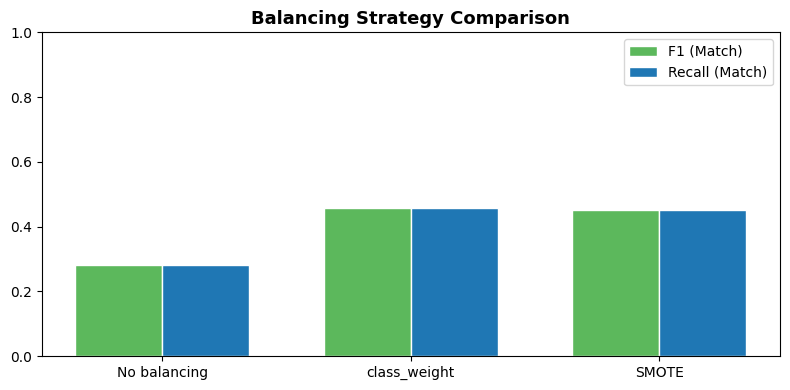

In [12]:
from imblearn.over_sampling import SMOTE
 
# Wersja 1 - bez balansowania
lr_none = LogisticRegression(random_state=42, max_iter=1000)
lr_none.fit(X_train, y_train)
y_pred_none = lr_none.predict(X_test)
 
# Wersja 2 - class_weight='balanced' (juz mamy jako lr)
# y_pred_lr z sekcji 5.3
 
# Wersja 3 - SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)
 
print("=== No balancing ===")
print(classification_report(y_test, y_pred_none, target_names=['No Match', 'Match']))
print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Match', 'Match']))
print("=== SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['No Match', 'Match']))
 
# Porownanie
balancing_results = pd.DataFrame([
    {'Strategy': 'No balancing',        'F1 (Match)': f1_score(y_test, y_pred_none,  pos_label=1), 'Recall (Match)': f1_score(y_test, y_pred_none,  pos_label=1, average=None)[1]},
    {'Strategy': 'class_weight',        'F1 (Match)': f1_score(y_test, y_pred_lr,    pos_label=1), 'Recall (Match)': f1_score(y_test, y_pred_lr,    pos_label=1, average=None)[1]},
    {'Strategy': 'SMOTE',               'F1 (Match)': f1_score(y_test, y_pred_smote, pos_label=1), 'Recall (Match)': f1_score(y_test, y_pred_smote, pos_label=1, average=None)[1]},
])
 
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(balancing_results))
width = 0.35
ax.bar([i - width/2 for i in x], balancing_results['F1 (Match)'], width,
       label='F1 (Match)', color='#5cb85c', edgecolor='white')
ax.bar([i + width/2 for i in x], balancing_results['Recall (Match)'], width,
       label='Recall (Match)', color='#1f77b4', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(balancing_results['Strategy'])
ax.set_ylim(0, 1)
ax.set_title('Balancing Strategy Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_exp_balancing.png', bbox_inches='tight')
plt.show()

| Strategy | F1 (Match) | Recall (Match) |
|---|---|---|
| No balancing | 0.28 | 0.19 |
| class_weight='balanced' | **0.46** | **0.67** |
| SMOTE | 0.45 | 0.66 |

Without any balancing the model almost completely ignores the Match class (recall=0.19),
confirming that handling class imbalance is essential. Both `class_weight='balanced'`
and SMOTE produce nearly identical results - `class_weight` wins marginally and is
simpler to apply, so it remains the chosen strategy for the final model.

## 7. Supporting Goal Analyses

### 7.1 Gender Differences in Model Predictions

=== Women ===
              precision    recall  f1-score   support

    No Match       0.91      0.74      0.82       779
       Match       0.38      0.69      0.49       176

    accuracy                           0.74       955
   macro avg       0.65      0.72      0.66       955
weighted avg       0.82      0.74      0.76       955



=== Men ===
              precision    recall  f1-score   support

    No Match       0.91      0.71      0.80       665
       Match       0.31      0.65      0.42       133

    accuracy                           0.70       798
   macro avg       0.61      0.68      0.61       798
weighted avg       0.81      0.70      0.73       798



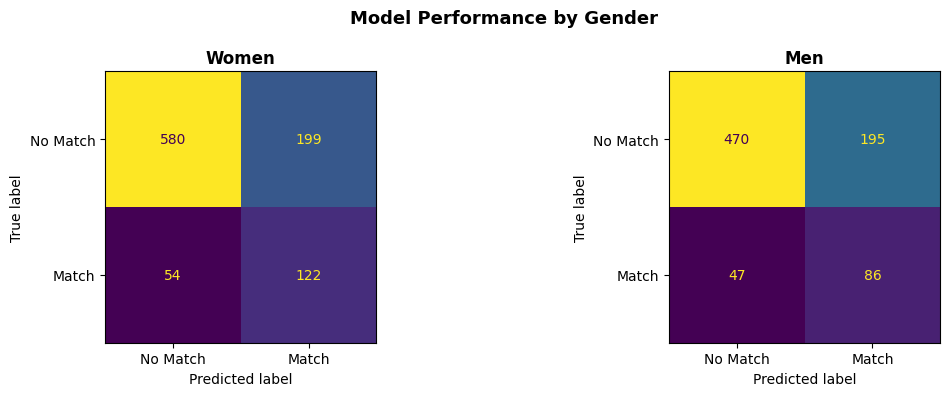

In [13]:
for gender, label in [(0, 'Women'), (1, 'Men')]:
    mask = test_df['gender'] == gender
    X_g = test_df.loc[mask, feature_cols]
    y_g = y_test[mask]
    y_pred_g = lr.predict(X_g)
 
    f1 = f1_score(y_g, y_pred_g, pos_label=1)
    acc = accuracy_score(y_g, y_pred_g)
    print(f"=== {label} ===")
    print(classification_report(y_g, y_pred_g, target_names=['No Match', 'Match']))
 
# Wykres porownawczy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (gender, label) in zip(axes, [(0, 'Women'), (1, 'Men')]):
    mask = test_df['gender'] == gender
    y_g = y_test[mask]
    y_pred_g = lr.predict(test_df.loc[mask, feature_cols])
    ConfusionMatrixDisplay(confusion_matrix(y_g, y_pred_g),
                           display_labels=['No Match', 'Match']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{label}', fontweight='bold')
 
plt.suptitle('Model Performance by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_gender_performance.png', bbox_inches='tight')
plt.show()

### 7.2 Stated vs. Revealed Preferences - Feature Importance

Compare stated preferences (attr1_1 etc.) with feature importance from the model.

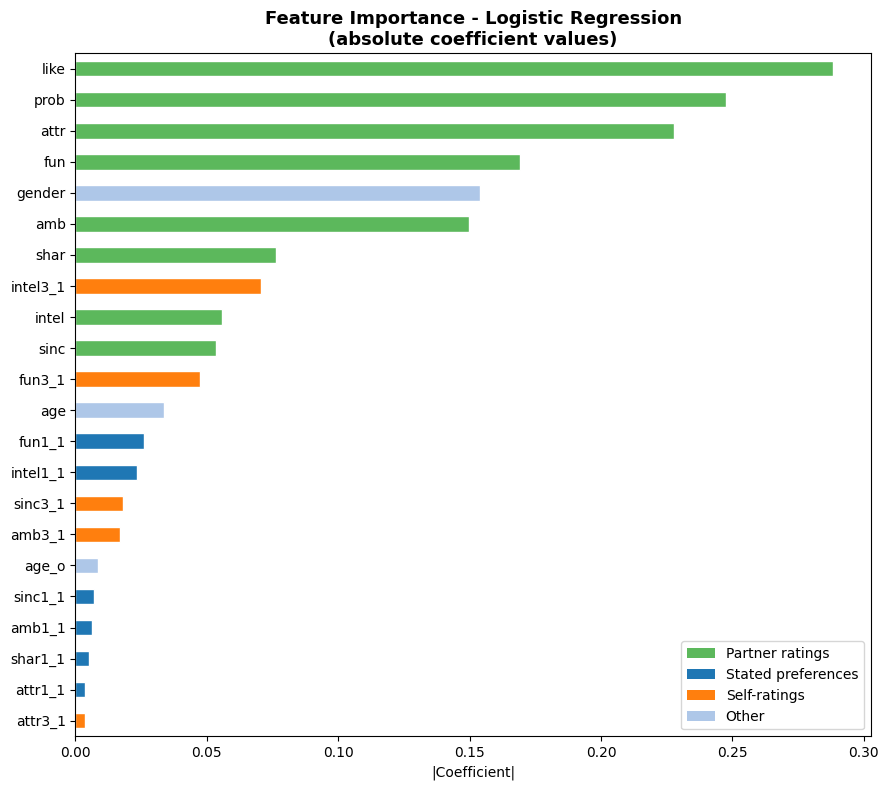

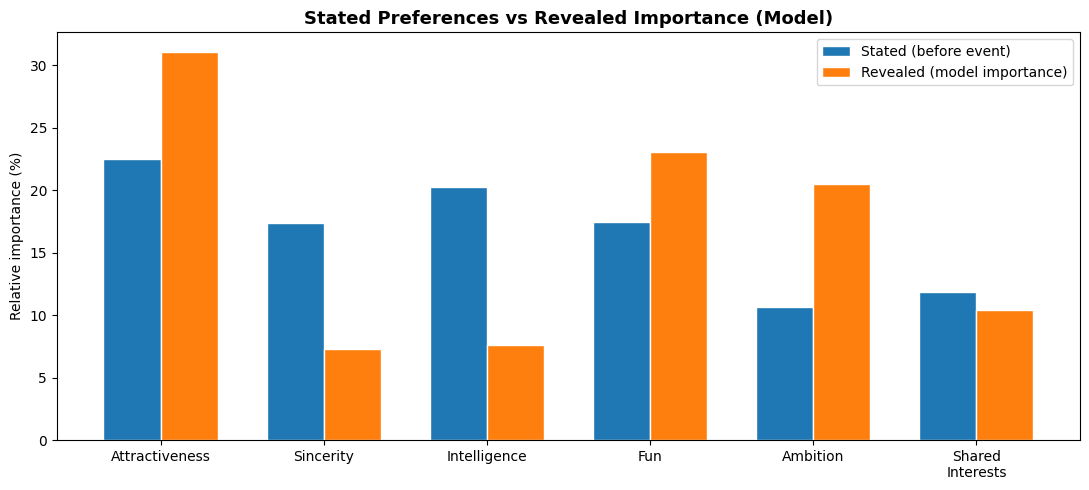

In [14]:
# Feature importance z Logistic Regression (absolutne wartosci wspolczynnikow)
coef = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=True)
 
# Kolorowanie - zielony = partner ratings, niebieski = preferences, pomaranczowy = self-ratings
color_map = {}
for col in feature_cols:
    if col in ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']:
        color_map[col] = '#5cb85c'   # partner ratings
    elif col.endswith('1_1'):
        color_map[col] = '#1f77b4'   # stated preferences
    elif col.endswith('3_1'):
        color_map[col] = '#ff7f0e'   # self-ratings
    else:
        color_map[col] = '#aec7e8'   # inne (gender, age)
 
colors = [color_map[c] for c in coef.index]
 
fig, ax = plt.subplots(figsize=(9, 8))
coef.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance - Logistic Regression\n(absolute coefficient values)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Coefficient|')
 
# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5cb85c', label='Partner ratings'),
    Patch(facecolor='#1f77b4', label='Stated preferences'),
    Patch(facecolor='#ff7f0e', label='Self-ratings'),
    Patch(facecolor='#aec7e8', label='Other'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()
 
# Stated vs Revealed
pref_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
labels = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared\nInterests']
 
stated = df[pref_cols].mean().values
revealed = np.abs(lr.coef_[0])[[feature_cols.index(c) for c in rating_cols]]
revealed_norm = (revealed / revealed.sum()) * 100
 
x = np.arange(len(labels))
width = 0.35
 
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, stated, width, label='Stated (before event)', color='#1f77b4', edgecolor='white')
ax.bar(x + width/2, revealed_norm, width, label='Revealed (model importance)', color='#ff7f0e', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Relative importance (%)')
ax.set_title('Stated Preferences vs Revealed Importance (Model)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_stated_vs_revealed_model.png', bbox_inches='tight')
plt.show()

### 7.3 Self-Assessment in Top Features

Check where self-rating columns (attr3_1 etc.) rank in feature importance.

In [15]:
self_cols = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']
coef_sorted = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=False)
 
print("=== Feature Importance Ranking ===")
for i, (col, val) in enumerate(coef_sorted.items()):
    tag = " ← SELF-RATING" if col in self_cols else ""
    print(f"{i+1:2d}. {col:<12} {val:.4f}{tag}")

=== Feature Importance Ranking ===
 1. like         0.2882
 2. prob         0.2474
 3. attr         0.2276
 4. fun          0.1690
 5. gender       0.1539
 6. amb          0.1499
 7. shar         0.0764
 8. intel3_1     0.0705 ← SELF-RATING
 9. intel        0.0558
10. sinc         0.0534
11. fun3_1       0.0475 ← SELF-RATING
12. age          0.0335
13. fun1_1       0.0261
14. intel1_1     0.0234
15. sinc3_1      0.0182 ← SELF-RATING
16. amb3_1       0.0169 ← SELF-RATING
17. age_o        0.0086
18. sinc1_1      0.0071
19. amb1_1       0.0064
20. shar1_1      0.0050
21. attr1_1      0.0037
22. attr3_1      0.0036 ← SELF-RATING


### 7.4 Pickiness Effect - Extended Analysis

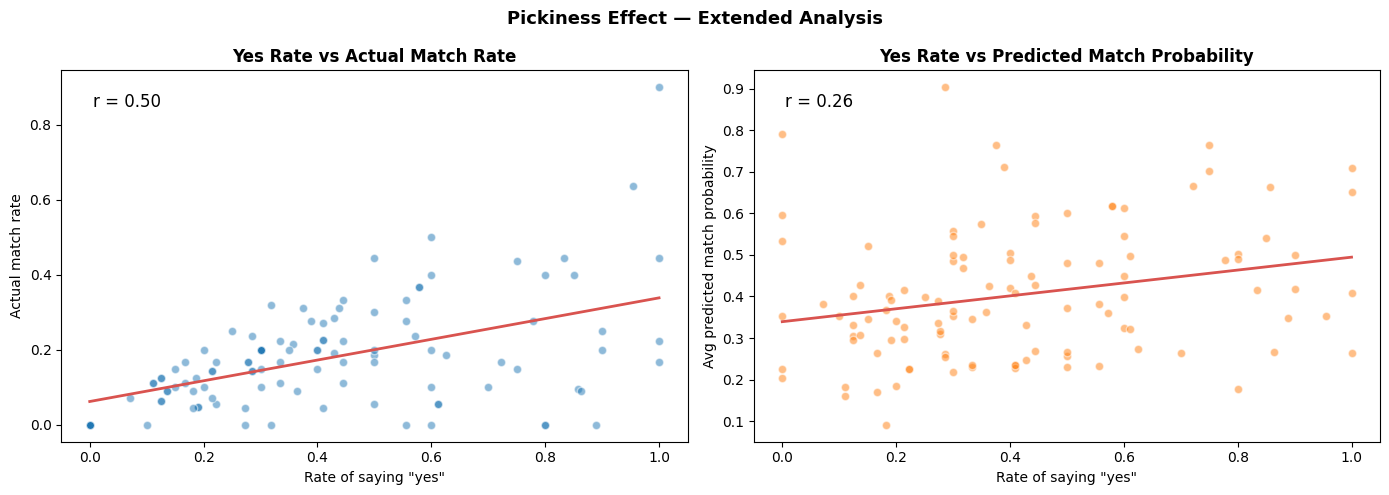

In [16]:
# Per participant: yes rate + predicted match probability
test_df = test_df.copy()
test_df['match_prob'] = lr.predict_proba(X_test)[:, 1]
 
person_stats = test_df.groupby('iid').agg(
    yes_rate=('dec', 'mean') if 'dec' in test_df.columns else ('match_prob', 'count'),
    match_rate=('match', 'mean'),
    avg_match_prob=('match_prob', 'mean')
).reset_index()
 
# Jesli dec nie ma w test_df uzyj oryginalnego df
person_stats2 = df[df['iid'].isin(test_iids)].groupby('iid').agg(
    yes_rate=('dec', 'mean'),
    match_rate=('match', 'mean')
).reset_index()
person_stats2 = person_stats2.merge(
    test_df.groupby('iid')['match_prob'].mean().reset_index(),
    on='iid'
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Yes rate vs actual match rate
axes[0].scatter(person_stats2['yes_rate'], person_stats2['match_rate'],
                alpha=0.5, color='#1f77b4', edgecolors='white')
m, b = np.polyfit(person_stats2['yes_rate'], person_stats2['match_rate'], 1)
x_line = np.linspace(0, 1, 100)
axes[0].plot(x_line, m*x_line+b, color='#d9534f', linewidth=2)
axes[0].set_xlabel('Rate of saying "yes"')
axes[0].set_ylabel('Actual match rate')
axes[0].set_title('Yes Rate vs Actual Match Rate', fontweight='bold')
r = person_stats2['yes_rate'].corr(person_stats2['match_rate'])
axes[0].text(0.05, 0.9, f'r = {r:.2f}', transform=axes[0].transAxes, fontsize=12)
 
# Yes rate vs predicted match probability
axes[1].scatter(person_stats2['yes_rate'], person_stats2['match_prob'],
                alpha=0.5, color='#ff7f0e', edgecolors='white')
m2, b2 = np.polyfit(person_stats2['yes_rate'], person_stats2['match_prob'], 1)
axes[1].plot(x_line, m2*x_line+b2, color='#d9534f', linewidth=2)
axes[1].set_xlabel('Rate of saying "yes"')
axes[1].set_ylabel('Avg predicted match probability')
axes[1].set_title('Yes Rate vs Predicted Match Probability', fontweight='bold')
r2 = person_stats2['yes_rate'].corr(person_stats2['match_prob'])
axes[1].text(0.05, 0.9, f'r = {r2:.2f}', transform=axes[1].transAxes, fontsize=12)
 
plt.suptitle('Pickiness Effect — Extended Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_pickiness_extended.png', bbox_inches='tight')
plt.show()

### 7.5 Golden Client Profile

=== Golden Client - Top 10 Profiles ===
 match_prob  gender  age  attr  fun  like  shar  prob  match
   0.973168     1.0 21.0  10.0 10.0  10.0  10.0  10.0      0
   0.970589     0.0 23.0  10.0 10.0  10.0  10.0  10.0      0
   0.970343     0.0 23.0  10.0 10.0  10.0  10.0  10.0      1
   0.970096     0.0 23.0  10.0 10.0  10.0  10.0  10.0      1
   0.969846     0.0 23.0  10.0 10.0  10.0  10.0  10.0      0
   0.966787     0.0 26.0   9.0 10.0   9.0   8.0  10.0      0
   0.965318     0.0 25.0  10.0 10.0   9.0   7.0  10.0      1
   0.965080     0.0 23.0  10.0 10.0  10.0   6.0   9.0      1
   0.960860     0.0 23.0  10.0 10.0  10.0  10.0   9.0      1
   0.960536     0.0 23.0  10.0 10.0  10.0  10.0   9.0      0

=== Golden Client - Average Profile (top 20%, n=351) ===
gender     0.47
age       26.13
attr       8.04
sinc       8.21
intel      8.39
fun        8.41
amb        7.75
shar       7.53
like       8.24
prob       7.55

Match rate — golden group: 41.03%
Match rate - overall:      17.63%


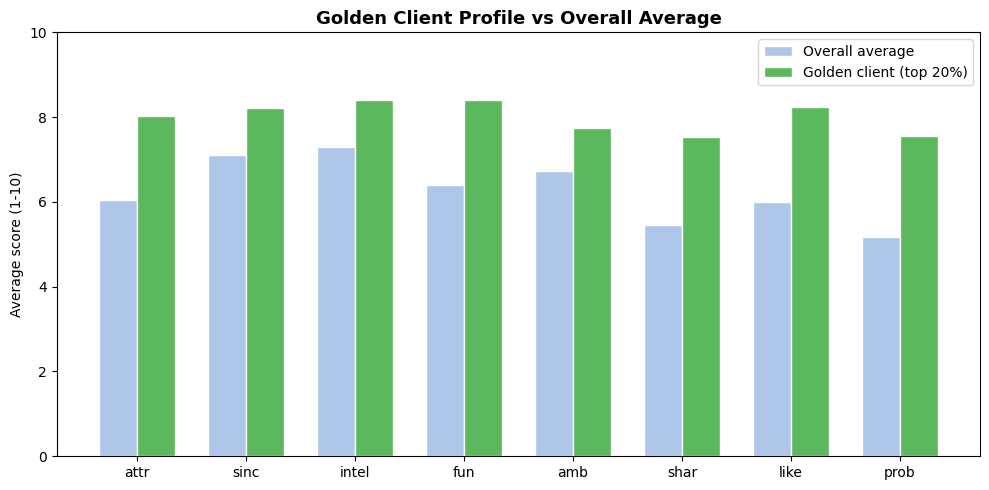

In [17]:

test_df['match_prob'] = lr.predict_proba(X_test)[:, 1]
 
# Top 10 rekordow
top10 = test_df.nlargest(10, 'match_prob')[
    ['match_prob', 'gender', 'age', 'attr', 'fun', 'like', 'shar', 'prob', 'match']
]
print("=== Golden Client - Top 10 Profiles ===")
print(top10.to_string(index=False))
 
# Sredni profil top 20%
threshold = test_df['match_prob'].quantile(0.8)
golden = test_df[test_df['match_prob'] >= threshold]
profile_cols = ['gender', 'age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
 
print(f"\n=== Golden Client - Average Profile (top 20%, n={len(golden)}) ===")
print(golden[profile_cols].mean().round(2).to_string())
print(f"\nMatch rate — golden group: {golden['match'].mean():.2%}")
print(f"Match rate - overall:      {test_df['match'].mean():.2%}")
 
# Wizualizacja profilu
fig, ax = plt.subplots(figsize=(10, 5))
rating_profile_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
golden_means = golden[rating_profile_cols].mean()
overall_means = test_df[rating_profile_cols].mean()
 
x = np.arange(len(rating_profile_cols))
width = 0.35
ax.bar(x - width/2, overall_means, width, label='Overall average', color='#aec7e8', edgecolor='white')
ax.bar(x + width/2, golden_means, width, label='Golden client (top 20%)', color='#5cb85c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(rating_profile_cols)
ax.set_ylim(0, 10)
ax.set_ylabel('Average score (1-10)')
ax.set_title('Golden Client Profile vs Overall Average', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_golden_client.png', bbox_inches='tight')
plt.show()

## 8. Summary & Conclusions

- Best performing model: *[TODO]*
- Most important features: *[TODO]*
- Golden client profile: *[TODO]*
- Key findings from supporting analyses: *[TODO]*